In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
)

sns.set_theme(style="whitegrid")

In [2]:
X_train = pd.read_csv('X_train_balanced.csv')
X_test = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train_balanced.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (15458, 6)
X_test shape: (2000, 6)


<b>Candidate Models</b>

<i>Logistic Regression: draws a straight-line  boundary between the classes. Fast, interpretable, but limited if the real relationship is more complex.

Random Forest: builds many decision trees on random subsets of data/features and averages their votes. Captures nonlinear patterns and interactions between features automatically.

Gradient Boosting: also an ensemble of trees, but built sequentially , each new tree specifically tries to correct the mistakes of the previous ones. Usually the strongest performer on tabular data like this, but more prone to overfitting if not tuned.</i>

In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

<b>Stratified cross-validation on the training set</b>

<i>
Instead of trusting a single train/validation split, StratifiedKFold splits the training data into 5 chunks, trains on 4 and validates on 1, five times over, rotating which chunk is held out.


"Stratified" ensures that each chunk keeps the same ~50/50 failure ratio as the full (SMOTE-balanced) training set, so no fold accidentally ends up with almost no failure examples. Averaging the 5 scores gives you a far more trustworthy estimate of each model's real performance than one split would.
</i>

In [4]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['precision', 'recall', 'f1', 'roc_auc', 'average_precision']

cv_results = {}

for model_name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv_strategy, scoring=scoring)
    cv_results[model_name] = {metric: scores[f'test_{metric}'].mean() for metric in scoring}
    print(f"{model_name} done")

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df

Logistic Regression done
Random Forest done
Gradient Boosting done


,precision,recall,f1,roc_auc,average_precision
Logistic Regression,0.821759,0.816665,0.819195,0.906254,0.906851
Random Forest,0.976790,0.990944,0.983812,0.999020,0.999012
Gradient Boosting,0.935677,0.970501,0.952757,0.990042,0.989003


<b>Fitting each model on full training data and evaluating on the held-out test set</b>

In [5]:
test_results = {}
fitted_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[model_name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    test_results[model_name] = {
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba)
    }

    print(f"\n{'=' * 60}")
    print(model_name)
    print('=' * 60)
    print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))


Logistic Regression
              precision    recall  f1-score   support

  No Failure       0.99      0.82      0.90      1932
     Failure       0.14      0.84      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.82      0.88      2000


Random Forest
              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.98      1932
     Failure       0.54      0.76      0.63        68

    accuracy                           0.97      2000
   macro avg       0.77      0.87      0.81      2000
weighted avg       0.98      0.97      0.97      2000


Gradient Boosting
              precision    recall  f1-score   support

  No Failure       1.00      0.93      0.96      1932
     Failure       0.31      0.91      0.47        68

    accuracy                           0.93      2000
   macro avg       0.66      0.92      0.72      2000
weighted avg       

<b>Confusion Matrices</b>

A table showing predicted vs actual

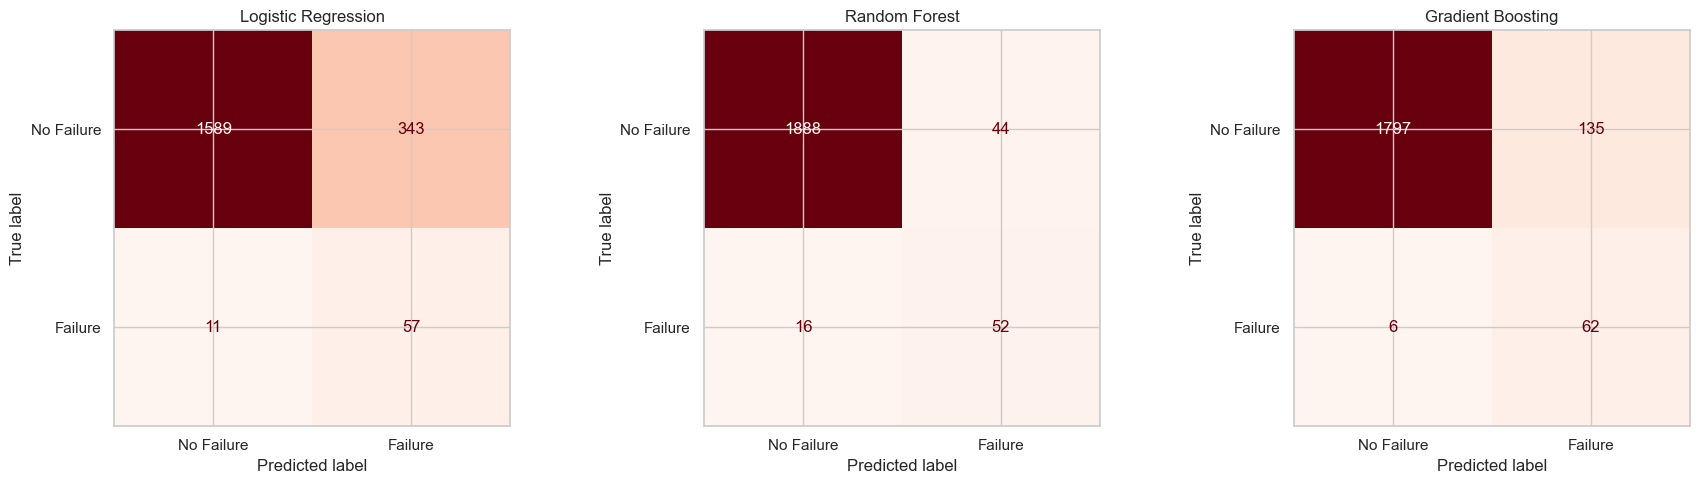

In [6]:
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))

for ax, (model_name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Failure', 'Failure'])
    disp.plot(ax=ax, colorbar=False, cmap='Reds')
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

<b>Precision Recall Curves</b>

when the model says failure, is it right (precision = TP / TP + FP) and of all real failures, how many did it catch (recall OR True Positive Rate = TP / TP + FN).

<i>PR-AUC is a single score that summarizes how well the model balances precision and recall across all thresholds , especially important when the positive class is rare. </i>

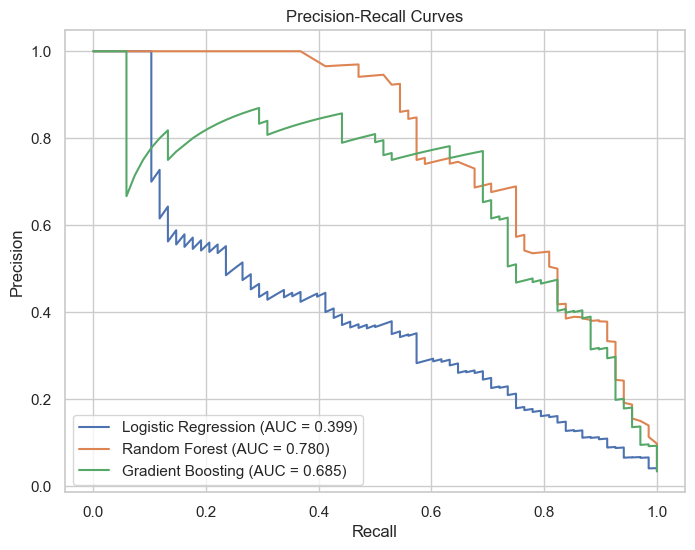

In [7]:
plt.figure(figsize=(8, 6))

for model_name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.show()

<b>ROC Curves</b>

plots true positive rate vs. false positive rate.

    In this case it can look overly optimistic since the data is imbalanced  because the no failure class is so large that  failures barely move the false-positive rate.

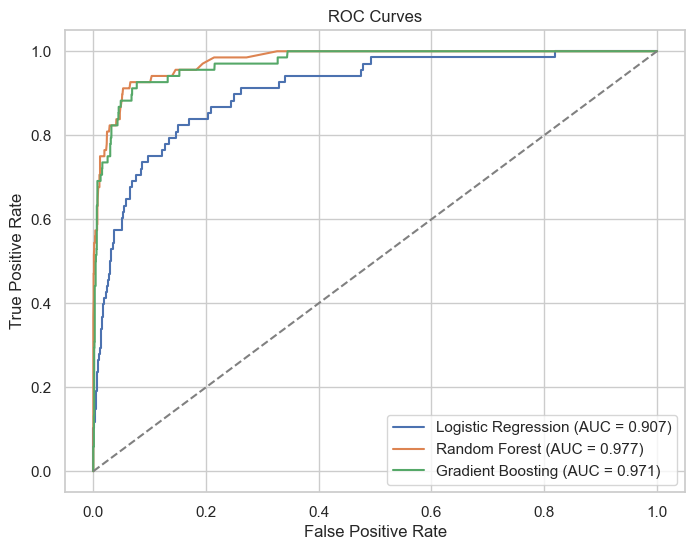

In [8]:
plt.figure(figsize=(8, 6))

for model_name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

<b>Feature importance from the best tree-based model</b>

<i>For tree-based models, I can ask , how much did each feature actually contribute to the splits that made predictions better. </i>

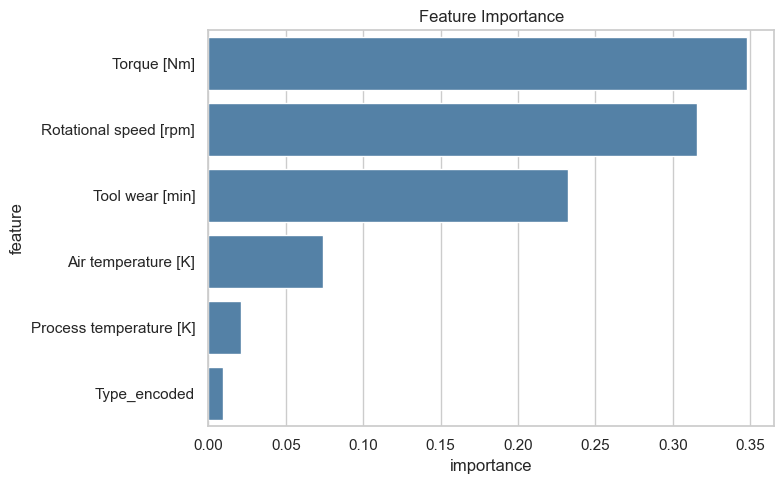

,feature,importance
3,Torque [Nm],0.347958
2,Rotational speed [rpm],0.315409
4,Tool wear [min],0.232275
0,Air temperature [K],0.073835
1,Process temperature [K],0.021081
5,Type_encoded,0.009442


In [9]:
best_tree_model = fitted_models['Gradient Boosting']
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_tree_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature', color='steelblue')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

importance_df

<b>Summary and Saving the best model</b>

In [10]:
summary_df = pd.DataFrame(test_results).T
print("Model comparison on test set:")
print(summary_df)

best_model_name = summary_df['pr_auc'].idxmax()
best_model = fitted_models[best_model_name]
print(f"\nBest model by PR-AUC: {best_model_name}")

joblib.dump(best_model, 'best_model.pkl')
print("Saved best_model.pkl")

Model comparison on test set:
                      roc_auc    pr_auc
Logistic Regression  0.907358  0.398973
Random Forest        0.977427  0.779582
Gradient Boosting    0.971498  0.685111

Best model by PR-AUC: Random Forest
Saved best_model.pkl
